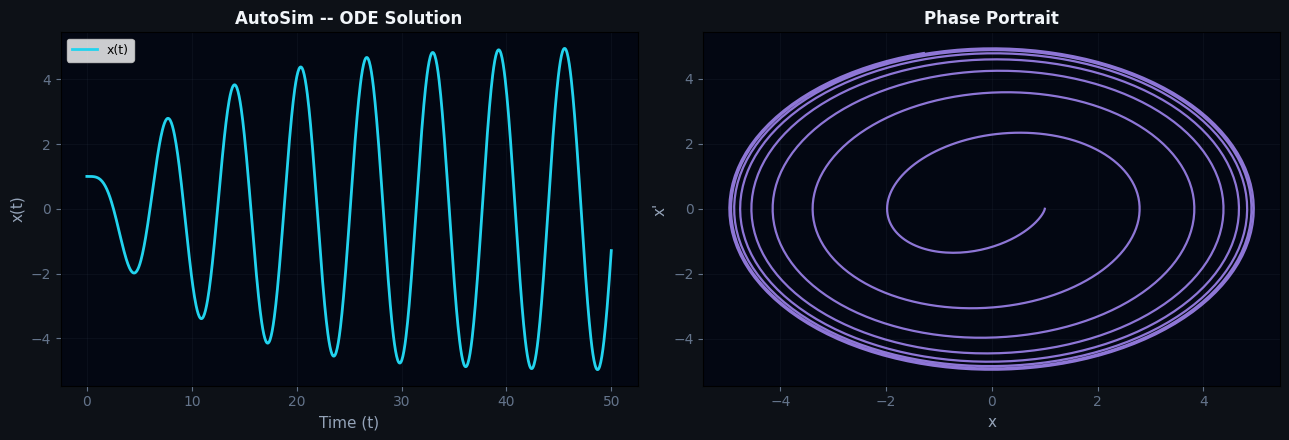

x_final = -1.289638
x_max   = 4.951946
x_min   = -4.965075
x_std   = 2.996208
nRMSE (coarse vs fine): 0.00172544   (< 1e-3 is excellent)


In [1]:
# =========================================================
# AutoSim ODE Solver Engine -- Generated Code
# Pipeline: Parse -> Generate -> Self-debug -> Evaluate
# =========================================================

# STEP 1 -- Problem Statement
# Solve the linear 2-order ODE:  x'' + 0.2*x' + x = cos(t)
# Initial conditions: x(0) = 1.0,  x'(0) = 0.0
# Time domain: t in [0.0, 50.0]
# Forcing function (RHS): cos(t)

import numpy as np
from scipy.integrate import solve_ivp


def ode_system(t, y, params=None):
    """
    ODE right-hand side in first-order system form.

    Parameters
    ----------
    t      : float          -- current time
    y      : array-like     -- state vector [x, x', ...]
    params : dict, optional -- named parameters

    Returns
    -------
    dydt : list -- derivatives of state vector
    """
    # 2nd-order ODE reduced to 1st-order system:
    # State: y = [x, x']  =>  derivatives = [x', x'']
    #
    # CoT:
    #   x'' = f(t) - 0.2*x' - 1.0*x - NL(x)
    #   where f(t) = np.cos(t)
    x_pos = y[0]   # x
    x_vel = y[1]   # x'
    f_t = np.cos(t)
    nl_term = 0.0
    pass  # no nonlinear terms
    x_acc = f_t - 0.2 * x_vel - 1.0 * x_pos - nl_term
    return [x_vel, x_acc]


def solver(y0, t_span, t_eval, params=None):
    """
    Solves the ODE system for all times in t_eval.

    Parameters
    ----------
    y0     : list or np.ndarray  -- initial conditions [y1_0, y2_0]
    t_span : tuple               -- (t_start, t_end)
    t_eval : np.ndarray          -- time points to evaluate solution at
    params : dict, optional      -- named parameters for the ODE

    Returns
    -------
    t : np.ndarray -- time array, shape (len(t_eval),)
    y : np.ndarray -- solution array, shape (2, len(t_eval))
    """
    # CoT: Method selection
    # Stiffness detected: False
    # -> RK45 (explicit Runge-Kutta, efficient for non-stiff problems)
    method = 'RK45'

    # Ensure y0 is a proper list
    y0 = list(np.atleast_1d(y0))

    sol = solve_ivp(
        fun=lambda t, y: ode_system(t, y, params),
        t_span=t_span,
        y0=y0,
        method=method,
        t_eval=t_eval,
        dense_output=False,
        rtol=1e-8,
        atol=1e-10,
    )

    if not sol.success:
        raise RuntimeError(f'ODE integration failed: {sol.message}')

    # sol.y shape: (n_vars, len(t_eval))
    return sol.t, sol.y


# ── Default parameters (edit as needed) ─────────────────────────────
y0     = [1.0, 0.0]
t_span = (0.0, 50.0)
t_eval = np.linspace(0.0, 50.0, 1000)
params = None

# --- EVALUATION ---
import matplotlib.pyplot as plt

t, y = solver(y0, t_span, t_eval, params)

# Plot results
labels = ['x(t)', "x'(t)", "x''(t)"][:len(y)]
colors = ['#22d3ee', '#a78bfa', '#34d399']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0d1117')

ax0 = axes[0]
for i, (yi, lbl, col) in enumerate(zip(y, labels, colors)):
    if i == 0:
        ax0.plot(t, yi, color=col, lw=2, label=lbl)
ax0.set_xlabel('Time (t)', fontsize=11, color='#94a3b8')
ax0.set_ylabel('x(t)', fontsize=11, color='#94a3b8')
ax0.set_title('AutoSim -- ODE Solution', fontsize=12, fontweight='bold', color='#f1f5f9')
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.15, color='#334155')
ax0.set_facecolor('#030712')
ax0.tick_params(colors='#64748b')

ax1 = axes[1]
ax1.plot(y[0], y[1], color='#a78bfa', lw=1.6, alpha=0.85)
ax1.set_xlabel('x', fontsize=11, color='#94a3b8')
ax1.set_ylabel("x'", fontsize=11, color='#94a3b8')
ax1.set_title('Phase Portrait', fontsize=12, fontweight='bold', color='#f1f5f9')
ax1.grid(True, alpha=0.15, color='#334155')
ax1.set_facecolor('#030712')
ax1.tick_params(colors='#64748b')

plt.tight_layout()
plt.show()

# Key statistics
x = y[0]
print('x_final =', round(float(x[-1]), 6))
print('x_max   =', round(float(x.max()), 6))
print('x_min   =', round(float(x.min()), 6))
print('x_std   =', round(float(x.std()), 6))

# Convergence check (optional)
t_coarse = np.linspace(t_span[0], t_span[1], 200)
t_fine   = np.linspace(t_span[0], t_span[1], 2000)
_, y_coarse = solver(y0, t_span, t_coarse, params)
_, y_fine   = solver(y0, t_span, t_fine,   params)
x_ci = np.interp(t_fine, t_coarse, y_coarse[0])
nrmse = (np.mean((y_fine[0] - x_ci)**2)**0.5) / (y_fine[0].max() - y_fine[0].min() + 1e-12)
print('nRMSE (coarse vs fine):', round(float(nrmse), 8), '  (< 1e-3 is excellent)')
